In [47]:
from pathlib import Path
import pandas as pd 
import folium as fl
import osmnx as ox
import matplotlib.pyplot as plt 
import geopandas as gpd

Code block to ensure files are read,created and saved in the right folders

In [48]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory    

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"processed"
figures_directory = project_root/"outputs"/"figures"
maps_directory = project_root/"outputs"/"maps"

for directory in [raw_data_directory,processed_data_directory,figures_directory,maps_directory]:
    directory.mkdir(parents=True,exist_ok=True)

print("Project Root:",project_root)
print("Folders are ready")

Project Root: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis
Folders are ready


In [49]:
#Saving Json locally so there is no need to also always get data

ox.settings.use_cache = True
ox.settings.log_console = True

accra_boundary = ox.geocode_to_gdf("Accra, Ghana")
accra_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-0.28427 5.52014, -0.28406 5.51965, ...",-0.284271,5.516926,-0.054857,5.667368,299395220,relation,12803764,5.55711,-0.201238,boundary,administrative,16,0.652835,city,Accra,"Accra, Korle-Klottey Municipal District, Great..."


In [50]:
print("Number of records:", len(accra_boundary))
print("CRS:", accra_boundary.crs)
print("Geometry type:", accra_boundary.geometry.geom_type.iloc[0])

accra_boundary[["display_name", "geometry"]]

Number of records: 1
CRS: epsg:4326
Geometry type: Polygon


,display_name,geometry
0,"Accra, Korle-Klottey Municipal District, Great...","POLYGON ((-0.28427 5.52014, -0.28406 5.51965, ..."


In [51]:
print(accra_boundary["display_name"].iloc[0])

Accra, Korle-Klottey Municipal District, Greater Accra Region, Ghana


The entire boundary for Greater different from the above which covers only some part

In [52]:
greater_accra_boundary = ox.geocode_to_gdf({"state":"Greater Accra Region","Country":"Ghana",})

In [53]:
print(greater_accra_boundary["display_name"].iloc[0])
print("CRS:",greater_accra_boundary.crs)
print("Geometry Type:",greater_accra_boundary.geometry.geom_type.iloc[0])

Greater Accra Region, Ghana
CRS: epsg:4326
Geometry Type: Polygon


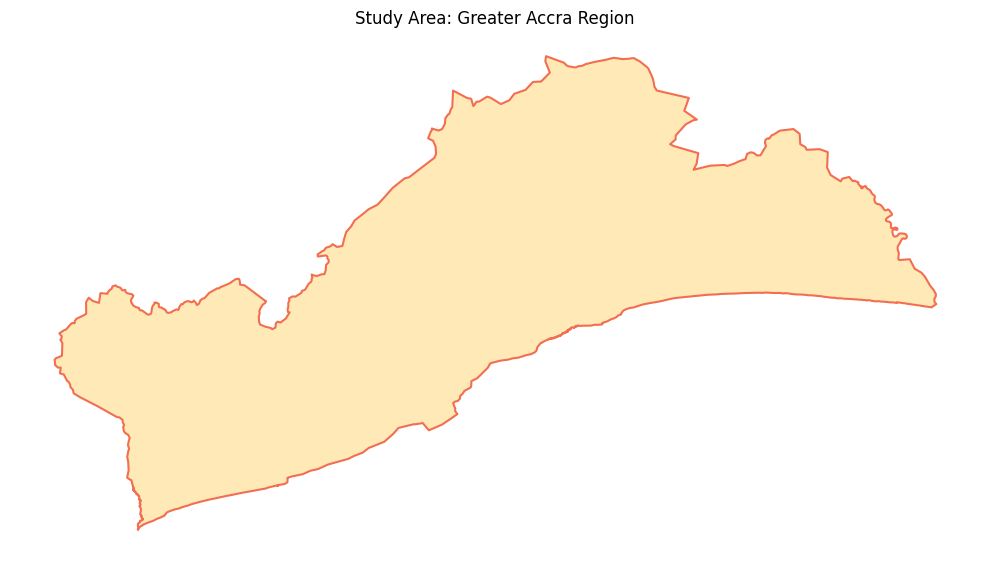

In [54]:
fig,ax = plt.subplots(figsize=(10,10))
greater_accra_boundary.plot(ax=ax,facecolor="#ffeab7",edgecolor="#f36e50",linewidth=1.5)
ax.set_title("Study Area: Greater Accra Region")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [55]:
#Saving of the boundary of greater Accra Locally

greater_accra_boundary_file =(raw_data_directory/"greater_accra_boundary.geojson")
greater_accra_boundary.to_file(greater_accra_boundary_file,driver="GeoJSON",)

print("File exist:",greater_accra_boundary_file.exists(),)
print("saved to:",greater_accra_boundary_file,)

File exist: True
saved to: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/data/raw/greater_accra_boundary.geojson


Handling of public documented data and changing values to spatial data

In [56]:
station_file = (raw_data_directory/"public_swap_stations.csv")

In [57]:
station_df = pd.read_csv(station_file)

In [58]:
station_df

,analysis_id,source_station_id,station_area,landmark,latitude,longitude,coordinate_quality,operator,source,source_accessed_date
0,PUB001,Station 002,Abelemkpe,Near Pan African TV,5.613139,-0.220528,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
1,PUB002,Station 003,Adenta,Housing Down,5.708822,-0.150986,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
2,PUB003,Station 004,Kaneshie,Near Vitamilk,5.570667,-0.239444,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
3,PUB004,Station 005,Kokomlemle,Opposite Auto Z,5.577616,-0.215024,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
4,PUB005,Station 006,Spintex,Adjacent Ecobank,5.628650,-0.090000,Landmark proxy,Kofa,Ghana Energy Commission,2026-08-12
5,PUB006,Station 007,Aviation,Aviation Social Centre,5.601183,-0.175749,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
6,PUB007,Station 008,Osu,Osu,5.562807,-0.187670,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12
7,PUB008,NaN,Haatso,ShaQ Express,5.665177,-0.202004,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12


In [59]:
# changing logitude an Latitude to spatial points 

station_points = gpd.points_from_xy(station_df["longitude"],station_df["latitude"],) 

In [60]:
#changing entire dataset to a spatial dataset 

station_gdf = gpd.GeoDataFrame(station_df.copy(),geometry=station_points,crs="EPSG:4326" )

In [61]:
station_gdf[["station_area","longitude","latitude","geometry"]]

,station_area,longitude,latitude,geometry
0,Abelemkpe,-0.220528,5.613139,POINT (-0.22053 5.61314)
1,Adenta,-0.150986,5.708822,POINT (-0.15099 5.70882)
2,Kaneshie,-0.239444,5.570667,POINT (-0.23944 5.57067)
3,Kokomlemle,-0.215024,5.577616,POINT (-0.21502 5.57762)
4,Spintex,-0.090000,5.628650,POINT (-0.09 5.62865)
5,Aviation,-0.175749,5.601183,POINT (-0.17575 5.60118)
6,Osu,-0.187670,5.562807,POINT (-0.18767 5.56281)
7,Haatso,-0.202004,5.665177,POINT (-0.202 5.66518)


In [62]:
print("Data type:",type(station_gdf))
print("CRS:",station_gdf.crs)
print("Missing Values:",station_gdf.geometry.isna().sum())


Data type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:4326
Missing Values: 0


In [63]:

print("same CRS:", station_gdf.crs == greater_accra_boundary.crs)

same CRS: True


Validating stations in study area against that in the station data .

In [64]:
study_area_geometry = (greater_accra_boundary.geometry.union_all())

In [65]:
station_gdf["inside_study_area"] = (station_gdf.geometry.covered_by(study_area_geometry))

In [66]:
station_gdf

,analysis_id,source_station_id,station_area,landmark,latitude,longitude,coordinate_quality,operator,source,source_accessed_date,geometry,inside_study_area
0,PUB001,Station 002,Abelemkpe,Near Pan African TV,5.613139,-0.220528,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.22053 5.61314),True
1,PUB002,Station 003,Adenta,Housing Down,5.708822,-0.150986,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.15099 5.70882),True
2,PUB003,Station 004,Kaneshie,Near Vitamilk,5.570667,-0.239444,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.23944 5.57067),True
3,PUB004,Station 005,Kokomlemle,Opposite Auto Z,5.577616,-0.215024,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.21502 5.57762),True
4,PUB005,Station 006,Spintex,Adjacent Ecobank,5.628650,-0.090000,Landmark proxy,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.09 5.62865),True
5,PUB006,Station 007,Aviation,Aviation Social Centre,5.601183,-0.175749,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.17575 5.60118),True
6,PUB007,Station 008,Osu,Osu,5.562807,-0.187670,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.18767 5.56281),True
7,PUB008,NaN,Haatso,ShaQ Express,5.665177,-0.202004,Public map coordinate,Kofa,Ghana Energy Commission,2026-08-12,POINT (-0.202 5.66518),True


In [67]:
print(station_gdf["inside_study_area"].value_counts())

inside_study_area
True    8
Name: count, dtype: int64


Visualizing the confirmed points 

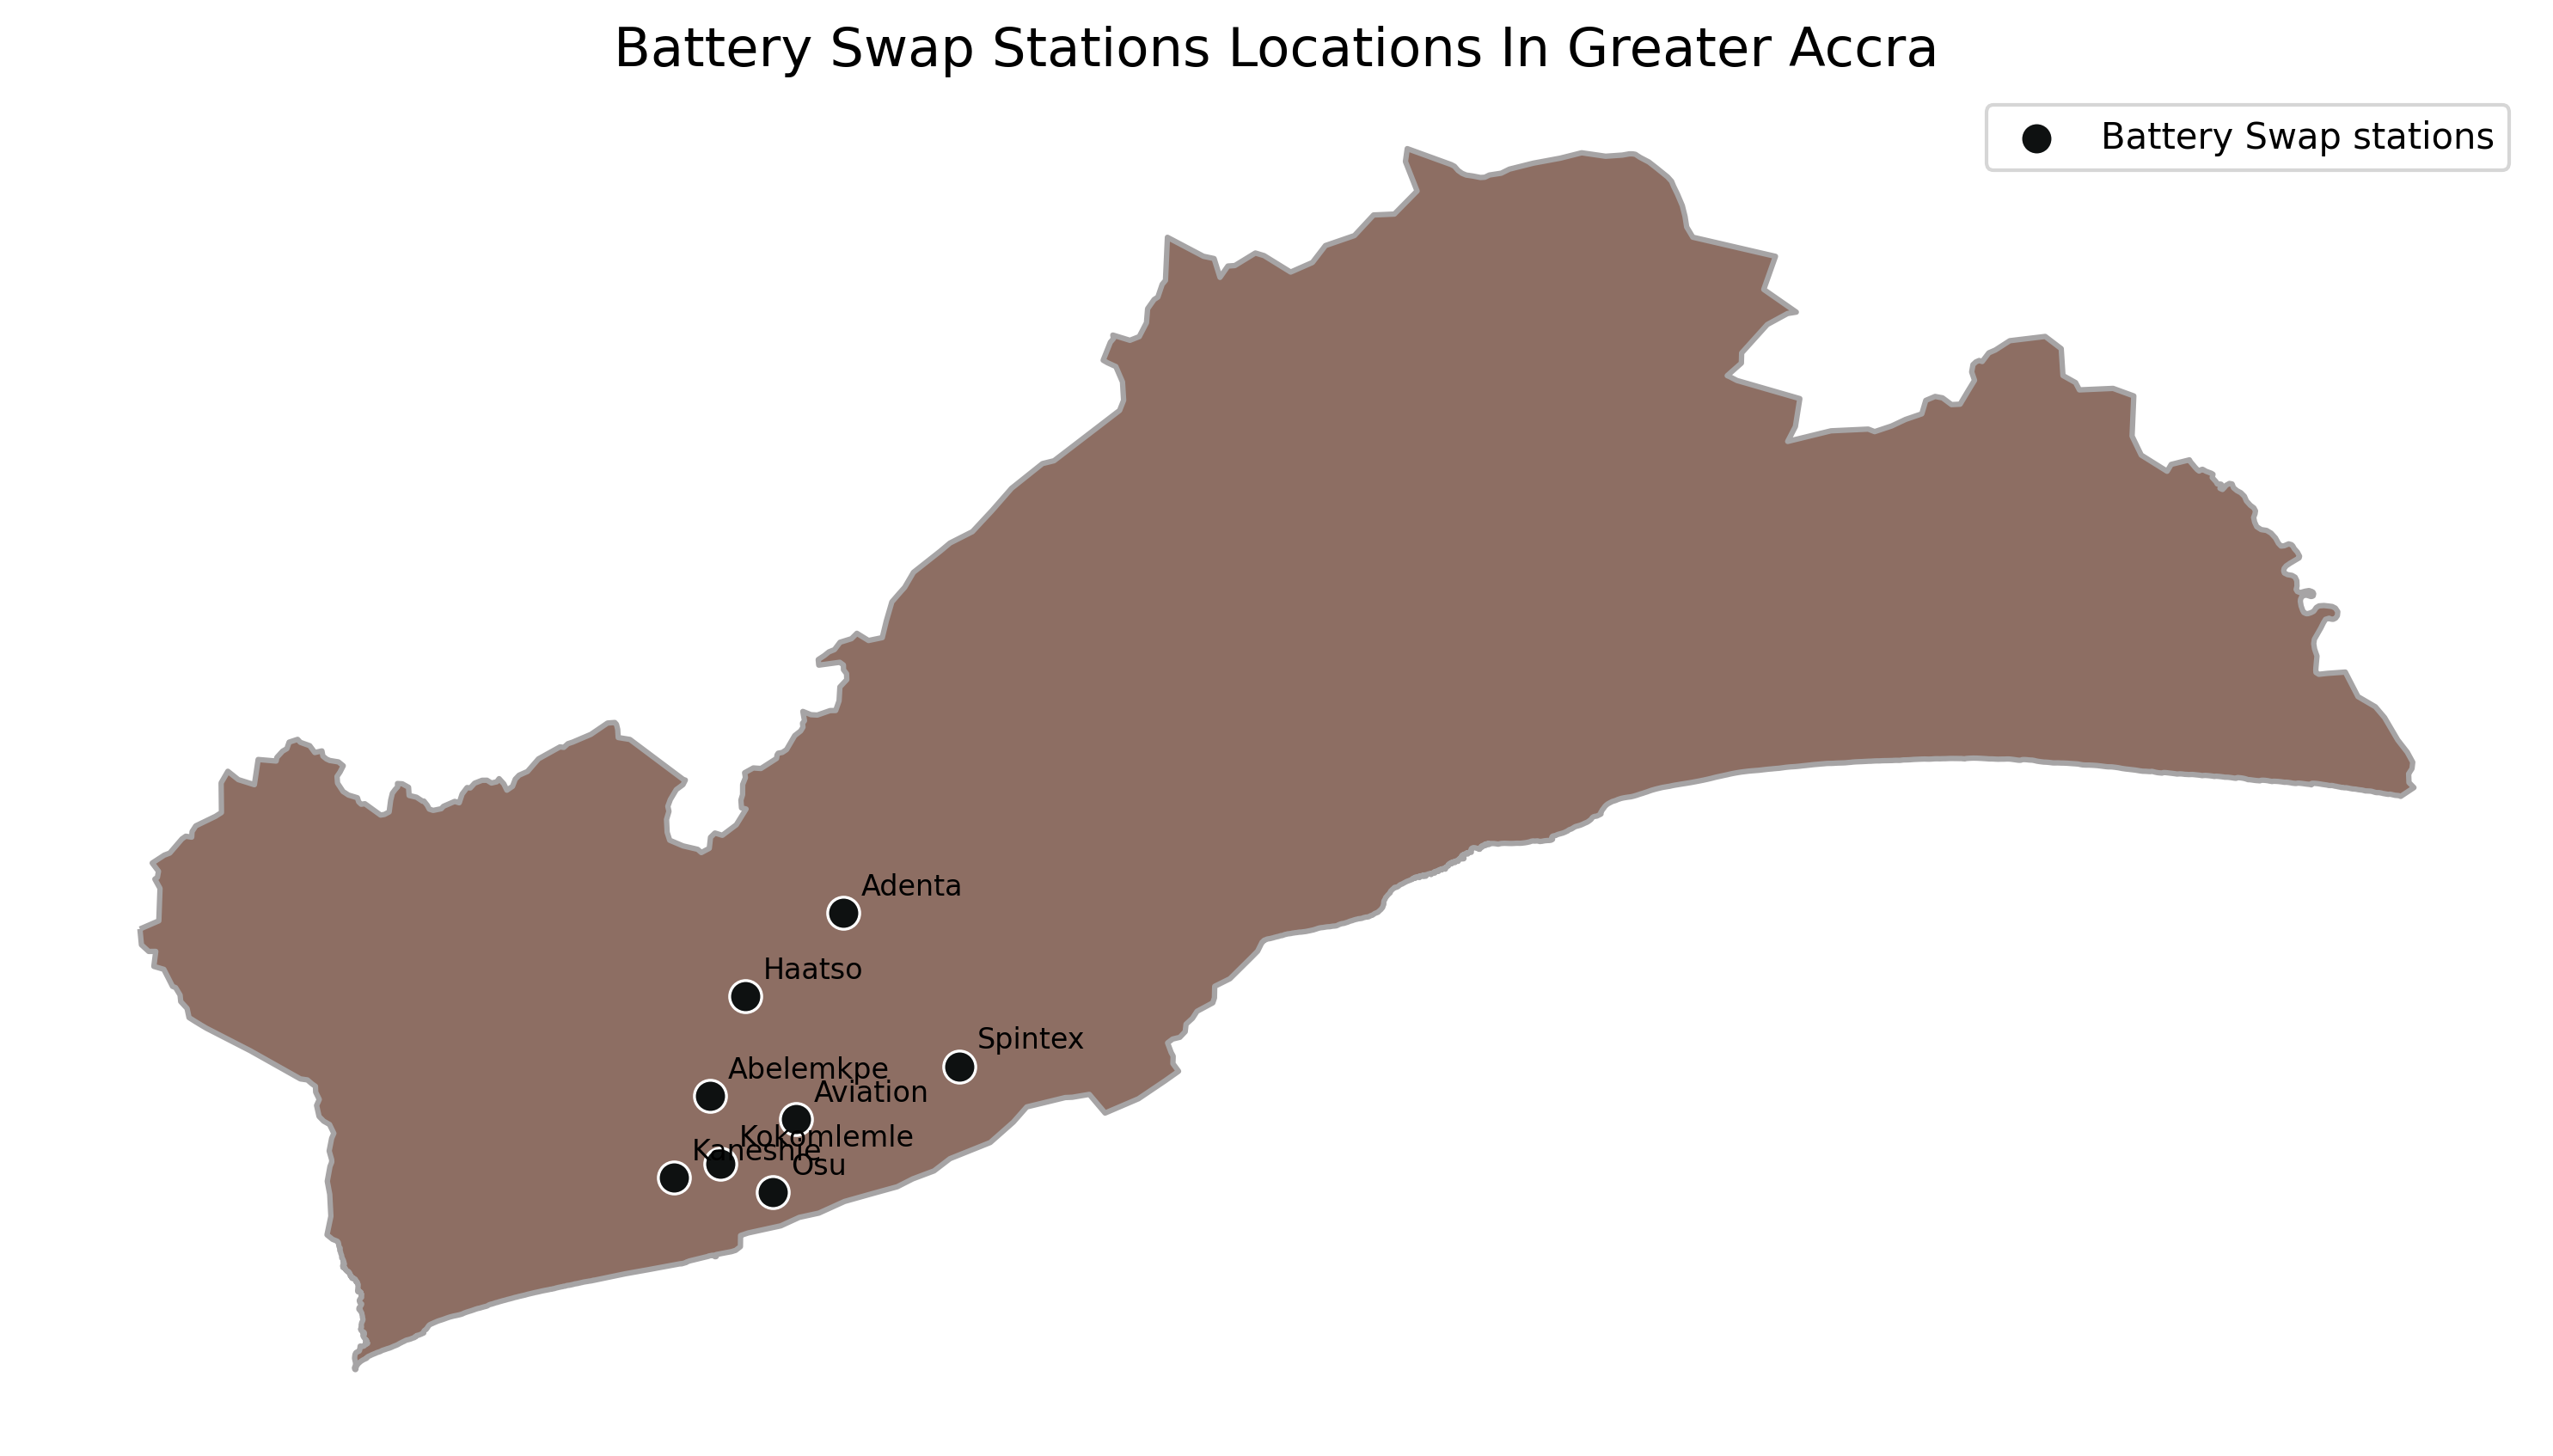

In [68]:
fig,ax = plt.subplots(figsize=(10,10),dpi=300)
greater_accra_boundary.plot(ax=ax,facecolor="#8d6e63",edgecolor="#a6a4a5",linewidth=1.5,zorder=1)
station_gdf.plot(ax=ax,color="#0e1111",edgecolor="white",linewidth=0.8,markersize=80,label="Battery Swap stations",zorder=2)

for _, station in station_gdf.iterrows():
    ax.annotate(text=station["station_area"],xy=(station.geometry.x,station.geometry.y,),
                xytext=(5,5),textcoords="offset points",fontsize=8,zorder=3,)
ax.set_title("Battery Swap Stations Locations In Greater Accra",fontsize=15)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

saving verified datasets and visualization .

In [69]:
verified_stations_file = (processed_data_directory/"verified_swap_station_points.geojson")
station_gdf.to_file(verified_stations_file,driver="GeoJSON",)

print("Saved to:",verified_stations_file)
print("File exist:",verified_stations_file.exists())

Saved to: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/data/processed/verified_swap_station_points.geojson
File exist: True


In [70]:
station_map_file = (figures_directory/"greater_accra_swap_stations_locations.png")
fig.savefig(station_map_file,dpi=300,bbox_inches="tight",)
print("Map saved to:",station_map_file)

Map saved to: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/outputs/figures/greater_accra_swap_stations_locations.png
